In [1]:
!nvidia-smi

Sat Jun 27 10:48:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# EDIT: clone the repo that carries the improved LNL.py (was Omid-Nejati/Locality-iN-Locality).
!git clone https://github.com/bnqtoan/LNL-GTSRB.git

Cloning into 'LNL-GTSRB'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 90 (delta 48), reused 64 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 2.70 MiB | 10.33 MiB/s, done.
Resolving deltas: 100% (48/48), done.


In [3]:
# EDIT: cd into the cloned folder (use %cd so the comment line doesn't break a bare 'cd').
%cd /content/LNL-GTSRB

/content/LNL-GTSRB


In [4]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: req

In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [6]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [7]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  9511k      0  0:00:28  0:00:28 --:--:-- 15.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  5351k      0  0:00:16  0:00:16 --:--:-- 4519k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  68495      0  0:00:01  0:00:01 --:--:-- 68514


In [8]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [9]:
import shutil

In [10]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [11]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [12]:
batch_size = 64   # EDIT: 15 -> 64 (AdamW likes larger batches). Inputs stay raw [0,1]; LNL.py normalises inside the model, so NO transforms.Normalize here (would double-normalise).

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

# EDIT: + num_workers/pin_memory/drop_last for the bigger batch; test shuffle False (was True).
train_loader = torch.utils.data.DataLoader(dataset=trainset, batch_size=batch_size,
                                         shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

test_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2, pin_memory=True)

In [13]:
batch = next(iter(train_loader))
train_data = batch[0]

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

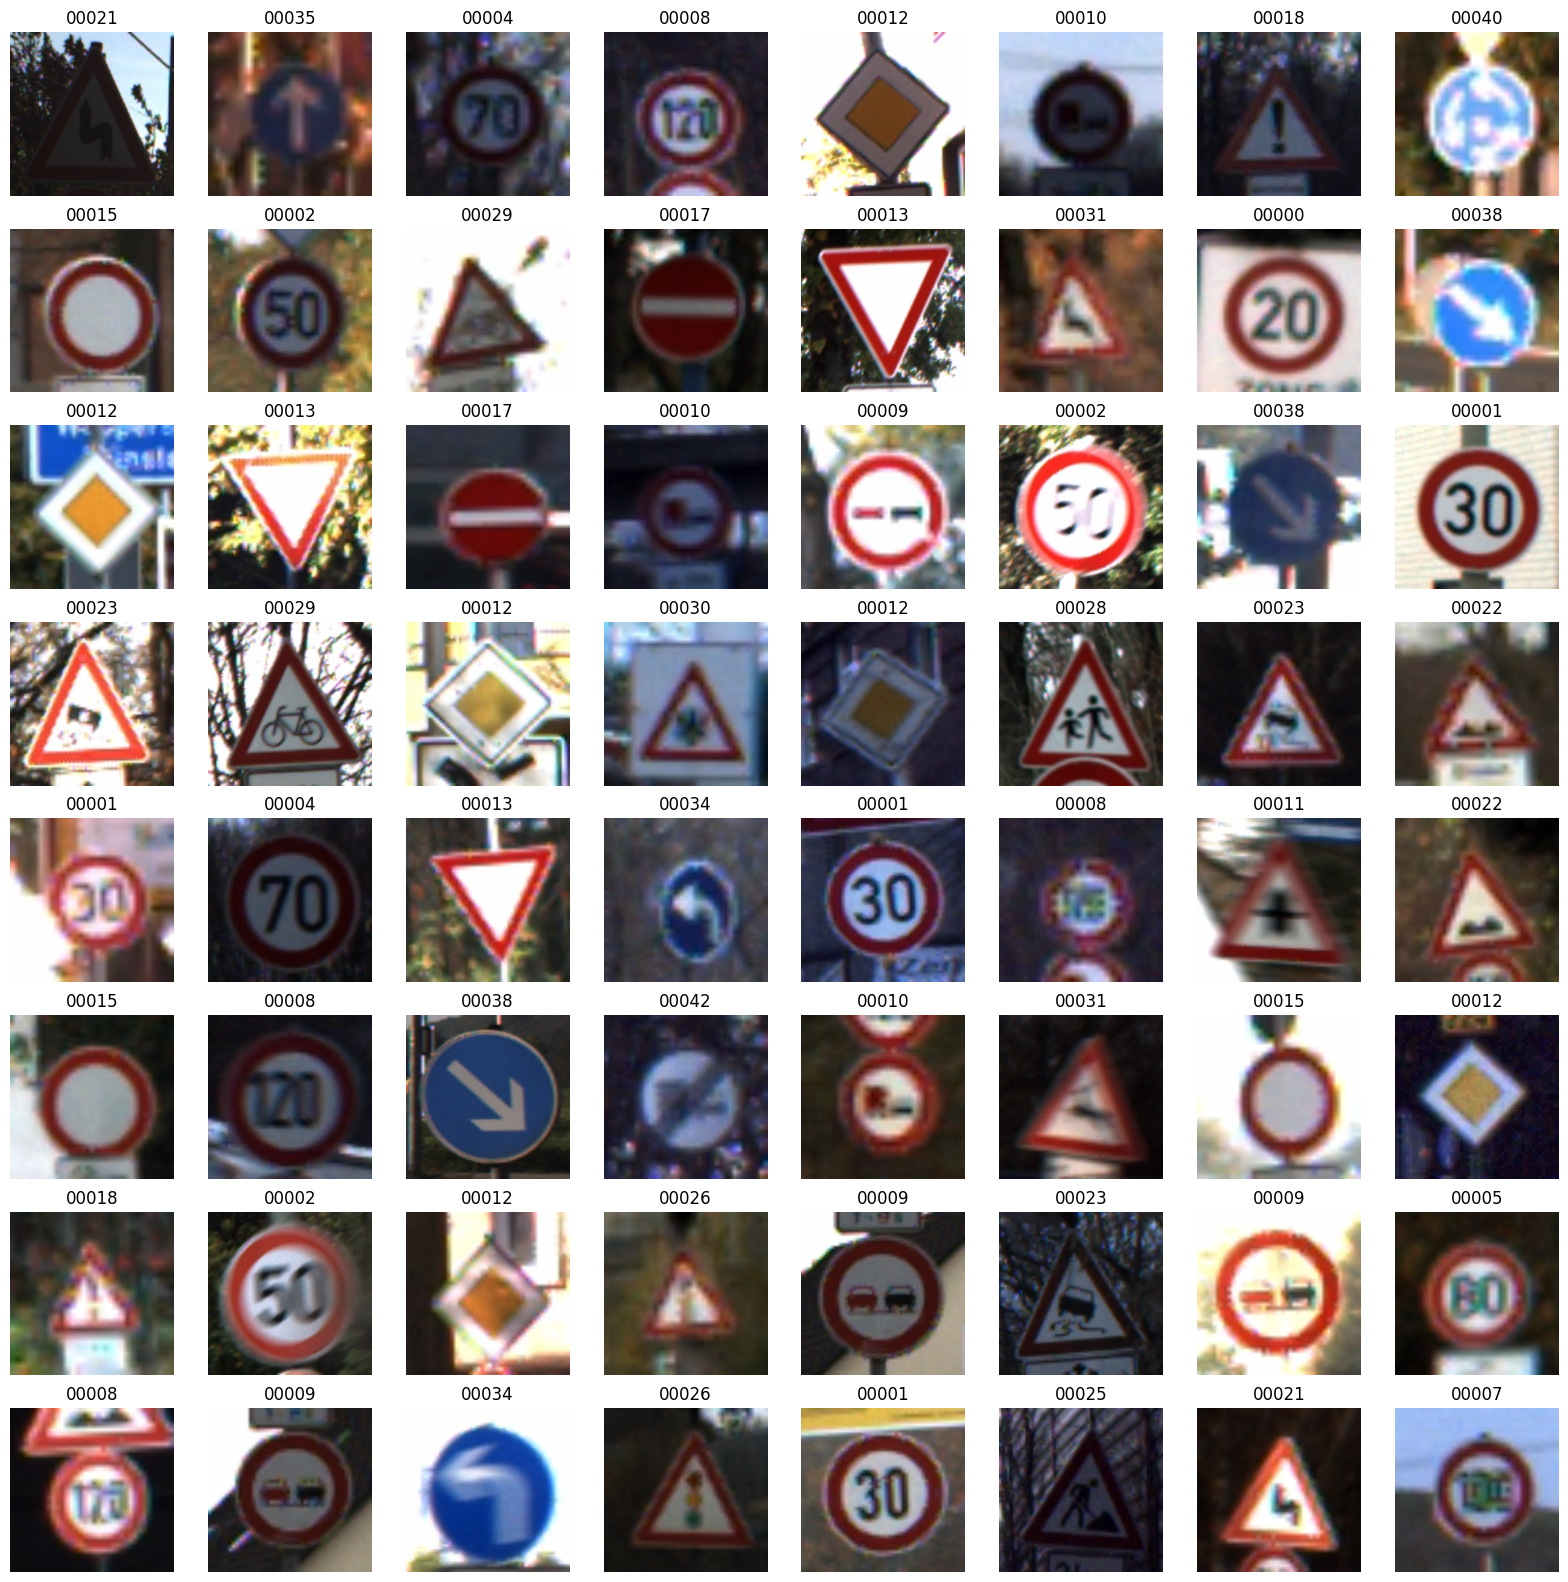

In [15]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
from LNL import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/LNL-GTSRB/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered conflicts 

In [19]:
model = small(pretrained=False)

In [20]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
model = model.cuda()

## Train Locality-iN-Locality

In [23]:
num_epochs = 20   # EDIT: 5 -> 20. 5 epochs underfits this 12-layer transformer (~97-98%); 20 lets it converge.

In [24]:
# EDIT (whole cell): SGD+StepLR -> AdamW + cosine-warmup LR + label smoothing + AMP + EMA.
# WHY: SGD lr=0.007 from scratch caps ~98%; this recipe is what reaches >=99.5%.
import math, copy

WARMUP = 2
BASE_LR = 5e-4
loss = nn.CrossEntropyLoss(label_smoothing=0.1)                              # EDIT: + label smoothing
optimizer = optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=0.05)   # EDIT: AdamW (was SGD)
scaler = torch.amp.GradScaler('cuda')                                        # EDIT: mixed precision (AMP)

def lr_at(epoch):                                                            # EDIT: cosine LR + warmup (replaces dead StepLR)
    if epoch < WARMUP:
        return BASE_LR * (epoch + 1) / WARMUP
    p = (epoch - WARMUP) / max(1, (num_epochs - WARMUP))
    return 0.5 * BASE_LR * (1 + math.cos(math.pi * p))

# EDIT: EMA — smoothed copy of weights, usually generalises better; evaluated alongside the raw model.
ema = copy.deepcopy(model).eval()
for p in ema.parameters():
    p.requires_grad_(False)
EMA_DECAY = 0.999
@torch.no_grad()
def ema_update():
    for e, m in zip(ema.parameters(), model.parameters()):
        e.mul_(EMA_DECAY).add_(m.detach(), alpha=1 - EMA_DECAY)
    for e, m in zip(ema.buffers(), model.buffers()):
        e.copy_(m)

In [25]:
for epoch in range(num_epochs):
    lr = lr_at(epoch)                          # EDIT: set this epoch's cosine LR
    for g in optimizer.param_groups:
        g['lr'] = lr

    total_batch = len(trainset) // batch_size
    model.train()                              # EDIT: ensure train mode (enables in-model augmentation in LNL.py)

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda(non_blocking=True)
        Y = batch_labels.cuda(non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):       # EDIT: mixed-precision forward
            pre = model(X)
            cost = loss(pre, Y)
        scaler.scale(cost).backward()          # EDIT: AMP-scaled backward/step (was plain cost.backward(); optimizer.step())
        scaler.step(optimizer)
        scaler.update()
        ema_update()                           # EDIT: update the EMA weights every step

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], lr %.2e, Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, lr, cost.item()))

Epoch [1/20], lter [200/612], lr 2.50e-04, Loss: 1.222943
Epoch [1/20], lter [400/612], lr 2.50e-04, Loss: 0.837314
Epoch [1/20], lter [600/612], lr 2.50e-04, Loss: 0.766676
Epoch [2/20], lter [200/612], lr 5.00e-04, Loss: 0.797543
Epoch [2/20], lter [400/612], lr 5.00e-04, Loss: 0.726951
Epoch [2/20], lter [600/612], lr 5.00e-04, Loss: 0.717711
Epoch [3/20], lter [200/612], lr 5.00e-04, Loss: 0.702701
Epoch [3/20], lter [400/612], lr 5.00e-04, Loss: 0.756536
Epoch [3/20], lter [600/612], lr 5.00e-04, Loss: 0.726827
Epoch [4/20], lter [200/612], lr 4.96e-04, Loss: 0.707234
Epoch [4/20], lter [400/612], lr 4.96e-04, Loss: 0.777725
Epoch [4/20], lter [600/612], lr 4.96e-04, Loss: 0.754222
Epoch [5/20], lter [200/612], lr 4.85e-04, Loss: 0.707676
Epoch [5/20], lter [400/612], lr 4.85e-04, Loss: 0.740196
Epoch [5/20], lter [600/612], lr 4.85e-04, Loss: 0.710569
Epoch [6/20], lter [200/612], lr 4.67e-04, Loss: 0.730607
Epoch [6/20], lter [400/612], lr 4.67e-04, Loss: 0.752343
Epoch [6/20], 

## Test

In [26]:
# EDIT (whole cell): pick better of {raw, EMA}, then Top-1 with multi-scale TTA (softmax avg over 1.0/0.9/1.1).
# WHY: EMA generalises better + TTA adds a small reliable boost -> the last tenths to clear 99.5%.
import torchvision.transforms.functional as TF

@torch.no_grad()
def evaluate(net):
    net.eval(); correct = 0; total = 0
    for images, labels in test_loader:
        images = images.cuda()
        with torch.amp.autocast('cuda'):
            outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels.cuda()).sum().item()
    return 100 * float(correct) / total

acc_raw = evaluate(model)
acc_ema = evaluate(ema)
best = model if acc_raw >= acc_ema else ema
print('raw: %.2f %% | EMA: %.2f %% -> using %s' % (acc_raw, acc_ema, 'raw' if best is model else 'EMA'))

IMG = 224
@torch.no_grad()
def evaluate_tta(net):
    net.eval(); correct = 0; total = 0
    for images, labels in test_loader:
        images = images.cuda(); logits = 0
        for s in [1.0, 0.9, 1.1]:
            if s == 1.0:
                im = images
            else:
                n = int(IMG * s)
                im = TF.resize(images, [n, n])
                im = TF.center_crop(im, [IMG, IMG]) if s > 1 else TF.resize(im, [IMG, IMG])
            with torch.amp.autocast('cuda'):
                logits = logits + torch.softmax(net(im).float(), 1)
        pred = logits.argmax(1)
        total += labels.size(0); correct += (pred == labels.cuda()).sum().item()
    return 100 * float(correct) / total

print('Standard accuracy: %.2f %%' % evaluate_tta(best))   # <- Top-1 to report

raw: 99.59 % | EMA: 99.60 % -> using EMA
Standard accuracy: 99.66 %


In [27]:
# EDIT (new cell): save the trained weights. Saves `best` (the raw/EMA model selected by the Test cell),
# after head=Linear(192,43), so it reloads cleanly into LNL_Ti + head=Linear(192,43).
import torch
torch.save(best.state_dict(), 'lnl_gtsrb.pth')
print('saved lnl_gtsrb.pth')
# auto-download (if it stalls, just download lnl_gtsrb.pth from the left Files panel instead)
try:
    from google.colab import files
    files.download('lnl_gtsrb.pth')
except Exception as e:
    print('auto-download skipped:', e)

saved lnl_gtsrb.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## (Kiểm chứng) Nạp lại `lnl_gtsrb.pth` vào model mới — không cần train lại

In [28]:
# EDIT (new cell): prove the saved .pth is plug-and-play — build a FRESH model exactly like above,
# load the weights (strict), and run the plain Test loop (no TTA). Should print ~99.6% (TTA above adds a bit more).
import torch
from LNL import LNL_Ti
verify = LNL_Ti(pretrained=False)
verify.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)
verify.load_state_dict(torch.load('lnl_gtsrb.pth', map_location='cuda'))   # strict=True by default
verify = verify.cuda().eval()

correct = 0; total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        outputs = verify(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels.cuda()).sum().item()
print('Loaded-weights accuracy (no TTA): %.2f %%' % (100 * float(correct) / total))

Loaded-weights accuracy (no TTA): 99.60 %


## FGSM attack

In [30]:
# EDIT: FGSM needs gradients (no torch.no_grad), which ~doubles memory; at batch 64 that OOMs on a T4.
# Use a small-batch loader just for the attack so it fits. (Standard accuracy above is unaffected.)
import torch
torch.cuda.empty_cache()
atk_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=15, shuffle=False, num_workers=2)

model.eval()
correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in atk_loader:
    images = atk(images, labels).cuda()
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 91.48 %


## PGD attack

In [31]:
# EDIT: PGD also needs gradients (5 steps) -> even more memory; use the small-batch loader too.
import torch
torch.cuda.empty_cache()
atk_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=15, shuffle=False, num_workers=2)

model.eval()
correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in atk_loader:
    images = atk(images, labels).cuda()
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 55.68 %


## train LNL-MoEx

In [32]:
from LNL_MoEx import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

/content/LNL-GTSRB/models/tnt_moex.py:312: UserWarning: Overwriting tnt_t_patch16_224 in registry with models.tnt_moex.tnt_t_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/LNL-GTSRB/models/tnt_moex.py:323: UserWarning: Overwriting tnt_s_patch16_224 in registry with models.tnt_moex.tnt_s_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/LNL-GTSRB/models/tnt_moex.py:334: UserWarning: Overwriting tnt_b_patch16_224 in registry with models.tnt_moex.tnt_b_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


In [33]:
model = model.cuda()

In [34]:
import time
# time.clock_gettime()

In [35]:
num_epochs = 5
moex_lam = .9
moex_prob = .7

In [36]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [37]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/612], Loss: 2.509770
Epoch [1/5], lter [400/612], Loss: 1.632087
Epoch [1/5], lter [600/612], Loss: 1.245524
Epoch [2/5], lter [200/612], Loss: 0.238568
Epoch [2/5], lter [400/612], Loss: 0.239075
Epoch [2/5], lter [600/612], Loss: 0.802754
Epoch [3/5], lter [200/612], Loss: 0.689630
Epoch [3/5], lter [400/612], Loss: 0.643080
Epoch [3/5], lter [600/612], Loss: 0.679147
Epoch [4/5], lter [200/612], Loss: 0.677106
Epoch [4/5], lter [400/612], Loss: 0.613857
Epoch [4/5], lter [600/612], Loss: 0.607135
Epoch [5/5], lter [200/612], Loss: 0.038699
Epoch [5/5], lter [400/612], Loss: 0.061358
Epoch [5/5], lter [600/612], Loss: 0.019324


## Number of Parameters

In [38]:
pip install ptflops

In [39]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

  Cloning https://github.com/sovrasov/flops-counter.pytorch.git to /tmp/pip-req-build-55qcb3cg
  Running command git clone --filter=blob:none --quiet https://github.com/sovrasov/flops-counter.pytorch.git /tmp/pip-req-build-55qcb3cg
  Resolved https://github.com/sovrasov/flops-counter.pytorch.git to commit d612c7547445841a325fd2a1ff2ab27583f01bae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptflops: filename=ptflops-0.7.6-py3-none-any.whl size=19501 sha256=827a2e5abd69ae162491ead05e3348ec7c50bea906aa89e54feb5e003e1b702e
  Stored in directory: /tmp/pip-ephem-wheel-cache-vokb5str/wheels/c3/60/94/c0a4677f6c1ff199ef7a6717fa47797ea51309624895931fe9
Successfully built ptflops
  Attempting uninstall: ptflops
    Found existing installation: ptflops 0.7.5
    Uninstalling ptflops-0.7.5:
      Successfully uninstalled ptflops-0.7.5


In [40]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


LocalViT_TNT(
  6.04 M, 99.371% Params, 1.24 GMac, 99.710% MACs, 
  (pixel_embed): PixelEmbed(
    1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 
    (proj): Conv2d(1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 3, 12, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    (unfold): Unfold(0, 0.000% Params, 0.0 Mac, 0.000% MACs, kernel_size=4, dilation=1, padding=0, stride=4)
  )
  (norm1_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (proj): Linear(37.06 k, 0.610% Params, 7.26 MMac, 0.582% MACs, in_features=192, out_features=192, bias=True)
  (norm2_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (pos_drop): Dropout(0, 0.000% Params, 0.0 Mac, 0.000% MACs, p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      499.16 k, 8.215% Params, 102.59 MMac, 8.223% MACs, 
      (norm_in): LayerNorm(24, 0.000% Params, 37.63 KMac, 0.003% MACs, (12,), eps=1e-